# (12) DAVIS: process, save data

host = ```any```, device = ```cuda:1```

**Motivation**:  <br>


In [1]:
# HIDE CODE


project_name = '_TemporalSC'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

## Step 0: save into dicts

### load data

In [3]:
from PIL import Image
from utils.imgproc import do_process


root = '/home/hadi/Datasets/DAVIS'
print(sorted(os.listdir(root)))

processed_dir = pjoin(root, 'processed')
os.makedirs(processed_dir, exist_ok=True)

['Annotations_unsupervised', 'ImageSets', 'JPEGImages', 'README.md', 'SOURCES.md']

### main videos

In [4]:
jpeg_imgs_dir = pjoin(root, 'JPEGImages', '480p')
len(os.listdir(jpeg_imgs_dir))

91

In [5]:
videos_color = {}
videos_bnw = {}
videos_wht = {}


for item in tqdm(sorted(os.listdir(jpeg_imgs_dir), key=alphanum_sort_key)):
    files = sorted(os.listdir(pjoin(jpeg_imgs_dir, item)), key=alphanum_sort_key)
    vid = []
    for f in files:
        img = Image.open(pjoin(jpeg_imgs_dir, item, f))
        vid.append(np.array(img))
    vid = np.stack(vid, axis=0)
    
    # convert to grayscale
    vid_bnw = vid.astype(np.float32)
    vid_bnw = np.mean(vid_bnw, axis=-1)
    vid_bnw = vid_bnw[:, np.newaxis]
    vid_bnw /= 255.0
    
    # whiten, contrast normalize, zscore
    vid_wht = tonp(do_process(
        torch.tensor(vid_bnw, device=device),
        device=device,
        crop_size=0,
    )[-1])
    
    # save in dict
    videos_color[item] = vid
    videos_bnw[item] = vid_bnw
    videos_wht[item] = vid_wht

100%|███████████████████████████████████████████| 91/91 [01:34<00:00,  1.04s/it]


#### save main videos

In [6]:
save_obj(
    obj=videos_color,
    file_name='DAVIS_color',
    save_dir=processed_dir,
    mode='npy',
)
save_obj(
    obj=videos_bnw,
    file_name='DAVIS_bnw',
    save_dir=processed_dir,
    mode='npy',
)
save_obj(
    obj=videos_wht,
    file_name='DAVIS_wht',
    save_dir=processed_dir,
    mode='npy',
)

[PROGRESS] 'DAVIS_color.npy' saved at
/home/hadi/Datasets/DAVIS/processed

[PROGRESS] 'DAVIS_bnw.npy' saved at
/home/hadi/Datasets/DAVIS/processed

[PROGRESS] 'DAVIS_wht.npy' saved at
/home/hadi/Datasets/DAVIS/processed

### mask videos

In [7]:
annot_dir = pjoin(root, 'Annotations_unsupervised', '480p')
len(os.listdir(annot_dir))

90

In [8]:
mask_videos = {}

for item in tqdm(sorted(os.listdir(annot_dir), key=alphanum_sort_key)):
    files = sorted(os.listdir(pjoin(annot_dir, item)), key=alphanum_sort_key)
    mask_video = []
    for f in files:
        img = Image.open(pjoin(annot_dir, item, f))
        mask_video.append(np.array(img))
    mask_video = np.stack(mask_video, axis=0)
    mask_videos[item] = mask_video

100%|███████████████████████████████████████████| 90/90 [00:07<00:00, 11.92it/s]


In [9]:
save_obj(
    obj=mask_videos,
    file_name='DAVIS_mask',
    save_dir=processed_dir,
    mode='npy',
)

[PROGRESS] 'DAVIS_mask.npy' saved at
/home/hadi/Datasets/DAVIS/processed

## trn/vld sets

In [10]:
trn_vld_split_dir = pjoin(root, 'ImageSets', '2017')
os.listdir(trn_vld_split_dir)

['val.txt', 'train.txt']

In [11]:
with open(pjoin(trn_vld_split_dir, 'val.txt'), 'r') as f:
    vld_set = [e.replace('\n', '') for e in f.readlines()]
    
with open(pjoin(trn_vld_split_dir, 'train.txt'), 'r') as f:
    trn_set = [e.replace('\n', '') for e in f.readlines()]
    
len(trn_set), len(vld_set)

(60, 30)

## plot

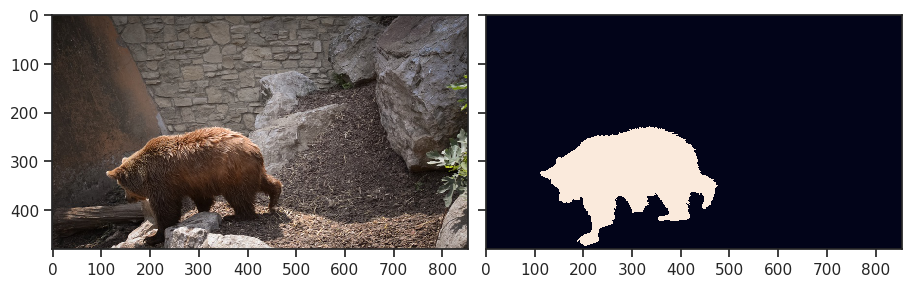

In [12]:
fig, axes = create_figure(1, 2, (9, 5), 'all', 'all')
axes[0].imshow(videos_color['bear'][40])
axes[1].imshow(mask_videos['bear'][40])
plt.show()

## Step 1: save cropped

In [10]:
davis_dir = '/home/hadi/Datasets/DAVIS/processed'
print(sorted(os.listdir(davis_dir)))

davis_wht = np.load(pjoin(davis_dir, 'DAVIS_wht.npy'), allow_pickle=True).item()

['DAVIS_bnw.npy', 'DAVIS_color.npy', 'DAVIS_mask.npy', 'DAVIS_wht.npy']

In [11]:
crop_size = 32
seq_len = 64

In [12]:
shapes = collections.defaultdict(list)
seq_lengths = collections.defaultdict(list)

for k, v in davis_wht.items():
    shapes[v.shape].append(k)
    seq_lengths[len(v)].append(k)

seq_lengths = dict(seq_lengths)
# shapes = dict(sorted(shapes))

<Axes: ylabel='Count'>

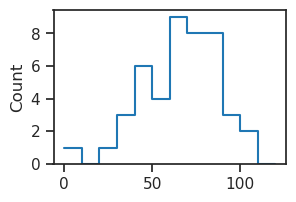

In [13]:
histplot(list(seq_lengths), bins=np.linspace(0, 120, 13))

In [14]:
accepted = [t for t in seq_lengths if t >= seq_len]
len(accepted) / len(seq_lengths)

0.6